In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GroupShuffleSplit
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import mean_squared_error, mean_absolute_error, log_loss, r2_score, confusion_matrix, accuracy_score, ConfusionMatrixDisplay, classification_report, precision_score, f1_score, recall_score
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import StratifiedKFold
import xgboost as xgb
import seaborn as sns

pd.set_option('display.max_columns', 999)
pd.set_option('display.max_rows', 999)


In [120]:
df_emotion = pd.read_csv('data.csv')
df_emotion.columns = df_emotion.columns.str.strip()

ft_space1 = ['amazement', 'solemnity', 'tenderness', 'nostalgia', 'calmness', 'power', 'joyful_activation', 'tension', 'sadness']

df_emotion = df_emotion.groupby("track id").agg({**{col: 'mean' for col in ft_space1}, 'genre': 'first'}).reset_index()
df_emotion.info()

<class 'pandas.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   track id           400 non-null    int64  
 1   amazement          400 non-null    float64
 2   solemnity          400 non-null    float64
 3   tenderness         400 non-null    float64
 4   nostalgia          400 non-null    float64
 5   calmness           400 non-null    float64
 6   power              400 non-null    float64
 7   joyful_activation  400 non-null    float64
 8   tension            400 non-null    float64
 9   sadness            400 non-null    float64
 10  genre              400 non-null    str    
dtypes: float64(9), int64(1), str(1)
memory usage: 34.5 KB


In [21]:
ft_space1 = ['amazement', 'solemnity', 'tenderness', 'nostalgia', 'calmness', 'power', 'joyful_activation', 'tension', 'sadness']

In [28]:
df_emotion['genre'] = df_emotion['genre'].astype('category')

In [30]:
df_emotion.info()

<class 'pandas.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   track id           400 non-null    int64   
 1   amazement          400 non-null    float64 
 2   solemnity          400 non-null    float64 
 3   tenderness         400 non-null    float64 
 4   nostalgia          400 non-null    float64 
 5   calmness           400 non-null    float64 
 6   power              400 non-null    float64 
 7   joyful_activation  400 non-null    float64 
 8   tension            400 non-null    float64 
 9   sadness            400 non-null    float64 
 10  genre              400 non-null    category
dtypes: category(1), float64(9), int64(1)
memory usage: 31.8 KB


In [75]:
def cv5(df, features, target, model):
    X = df[features].values
    y = df[target].values
    kf = StratifiedKFold(5, shuffle=True, random_state=42)

    acc, prec, f1 = [], [], []
    y_true_all, y_pred_all = [], []

    for tr, te in kf.split(X, y):
        model.fit(X[tr], y[tr])
        pred = model.predict(X[te])

        acc.append(model.score(X[te], y[te]))
        prec.append(precision_score(y[te], pred, average="macro"))
        f1.append(f1_score(y[te], pred, average="macro"))

        y_true_all.extend(y[te])
        y_pred_all.extend(pred)

    print("5-Fold Cross Validation Results")
    print("-------------------------------")
    print(f"Accuracy : {np.mean(acc):.3f}")
    print(f"Precision: {np.mean(prec):.3f}")
    print(f"F1 Score : {np.mean(f1):.3f}")

    print("\nConfusion Matrix")
    print("----------------")
    print(confusion_matrix(y_true_all, y_pred_all))


In [46]:
distribution = df_emotion["genre"].value_counts(normalize=True)
print(distribution)

genre
classical     0.25
electronic    0.25
pop           0.25
rock          0.25
Name: proportion, dtype: float64


In [39]:
proportional_accuracy = np.sum(distribution ** 2)
print(f"Proportional random guess accuracy: {proportional_accuracy:.4f} ({proportional_accuracy*100:.2f}%)")

Proportional random guess accuracy: 0.2500 (25.00%)


<Axes: xlabel='genre'>

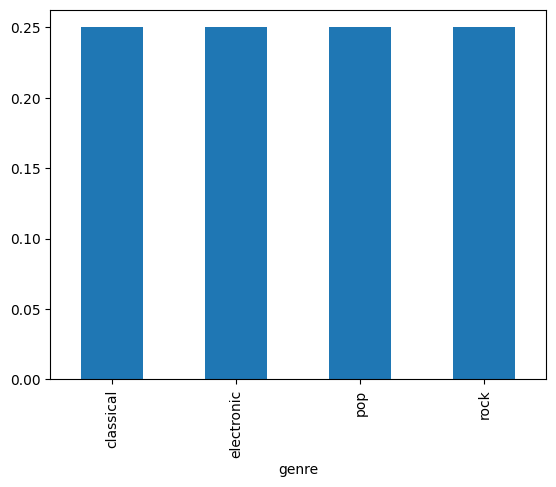

In [40]:
distribution.plot(kind='bar')

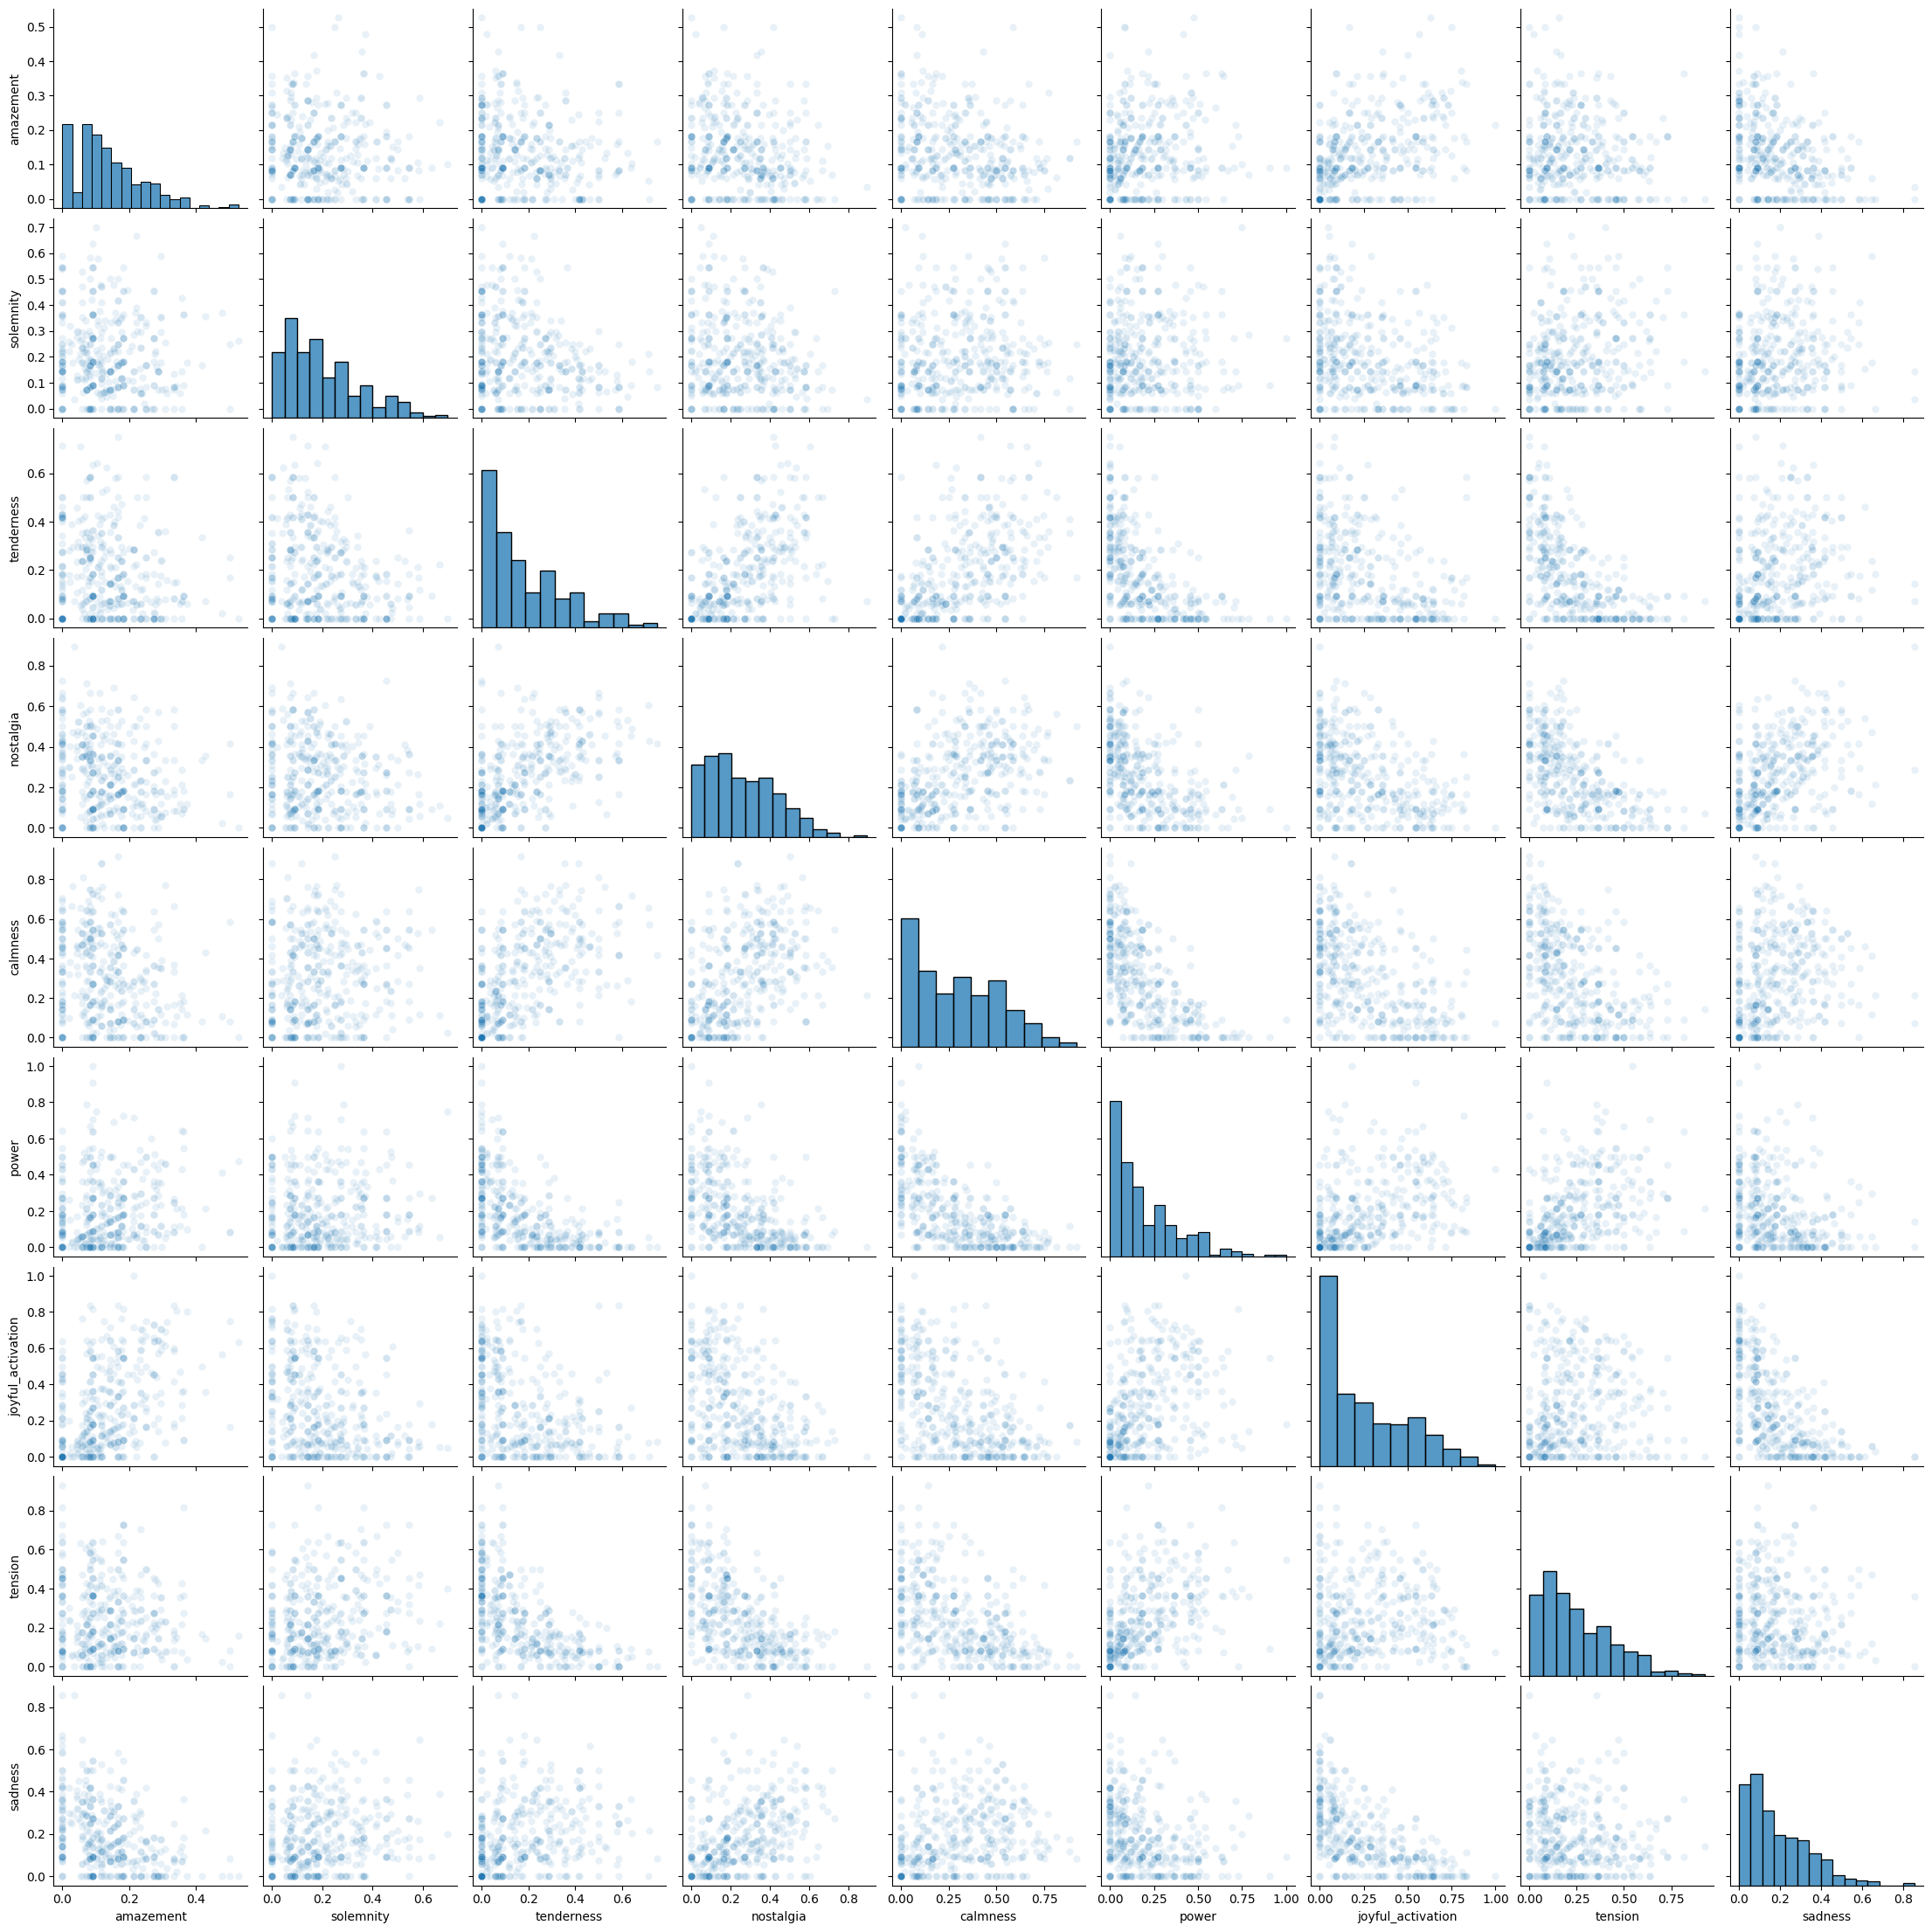

In [41]:
sns.pairplot(df_emotion.loc[:,ft_space1+['genre']], plot_kws={'alpha':.1});

In [54]:
cv5(df_emotion, ft_space1, "genre", RandomForestClassifier(n_estimators=1000, n_jobs=-1, random_state=0))

5-Fold Cross Validation Results
-------------------------------
Accuracy : 0.648
Precision: 0.647
F1 Score : 0.640

Confusion Matrix
----------------
[[63 17 12  8]
 [ 8 83  2  7]
 [15 18 42 25]
 [ 6  8 15 71]]


In [57]:
xgb_def = xgb.XGBClassifier(eval_metric='mlogloss', n_estimators=1000, n_jobs=-1, random_state=0)

In [58]:
le = LabelEncoder()
df_emotion["genre_enc"] = le.fit_transform(df_emotion["genre"])
cv5(df_emotion, ft_space1, "genre_enc", xgb_def)

5-Fold Cross Validation Results
-------------------------------
Accuracy : 0.715
Precision: 0.723
F1 Score : 0.713

Confusion Matrix
----------------
[[76  8 11  5]
 [ 4 84  9  3]
 [14 13 53 20]
 [ 8  2 17 73]]


In [76]:
xgb1 = xgb.XGBClassifier(n_estimators=5000, learning_rate=.01, eval_metric='mlogloss', n_jobs=-1, random_state=0)

In [60]:
cv5(df_emotion, ft_space1, "genre_enc", xgb1)

5-Fold Cross Validation Results
-------------------------------
Accuracy : 0.700
Precision: 0.710
F1 Score : 0.698

Confusion Matrix
----------------
[[74  8 12  6]
 [ 4 83  9  4]
 [14 14 51 21]
 [ 8  2 18 72]]


In [85]:
import numpy as np
import xgboost as xgb
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import precision_score, f1_score, confusion_matrix

def cv5_xgb_depth_sweep(df, features, target, num_boost_round=500, early_stopping_rounds=10):
    """
    5-Fold Stratified CV using xgboost.train() with early stopping.
    Sweeps max_depth from 1 to 10 and outputs metrics for each depth.
    """
    X = df[features].values
    y = df[target].values
    kf = StratifiedKFold(5, shuffle=True, random_state=42)

    for depth in range(1, 11):  # max_depth 1 to 10
        acc, prec, f1 = [], [], []
        y_true_all, y_pred_all = [], []

        params = {
            'objective': 'multi:softmax',
            'num_class': len(np.unique(y)),
            'eval_metric': 'mlogloss',
            'seed': 42,
            'max_depth': depth
        }

        for tr_idx, te_idx in kf.split(X, y):
            # Split train fold into train/validation for early stopping
            X_train, X_val, y_train, y_val = train_test_split(
                X[tr_idx], y[tr_idx], test_size=0.2, stratify=y[tr_idx], random_state=42
            )

            dtrain = xgb.DMatrix(X_train, label=y_train)
            dval = xgb.DMatrix(X_val, label=y_val)
            dtest = xgb.DMatrix(X[te_idx], label=y[te_idx])

            evals = [(dtrain, 'train'), (dval, 'eval')]

            bst = xgb.train(
                params=params,
                dtrain=dtrain,
                num_boost_round=num_boost_round,
                evals=evals,
                early_stopping_rounds=early_stopping_rounds,
                verbose_eval=False
            )

            pred = bst.predict(dtest)

            acc.append(np.mean(pred == y[te_idx]))
            prec.append(precision_score(y[te_idx], pred, average="macro"))
            f1.append(f1_score(y[te_idx], pred, average="macro"))

            y_true_all.extend(y[te_idx])
            y_pred_all.extend(pred)

        print(f"\nMax Depth = {depth}")
        print("--------------------------")
        print(f"Accuracy : {np.mean(acc):.3f}")
        print(f"Precision: {np.mean(prec):.3f}")
        print(f"F1 Score : {np.mean(f1):.3f}")
        # print("Confusion Matrix:")
        # print(confusion_matrix(y_true_all, y_pred_all))

In [86]:
cv5_xgb_depth_sweep(df_emotion, ft_space1, "genre_enc", num_boost_round=5000, early_stopping_rounds=10)


Max Depth = 1
--------------------------
Accuracy : 0.630
Precision: 0.633
F1 Score : 0.624

Max Depth = 2
--------------------------
Accuracy : 0.682
Precision: 0.684
F1 Score : 0.681

Max Depth = 3
--------------------------
Accuracy : 0.707
Precision: 0.708
F1 Score : 0.704

Max Depth = 4
--------------------------
Accuracy : 0.693
Precision: 0.694
F1 Score : 0.688

Max Depth = 5
--------------------------
Accuracy : 0.695
Precision: 0.695
F1 Score : 0.691

Max Depth = 6
--------------------------
Accuracy : 0.672
Precision: 0.677
F1 Score : 0.671

Max Depth = 7
--------------------------
Accuracy : 0.655
Precision: 0.655
F1 Score : 0.652

Max Depth = 8
--------------------------
Accuracy : 0.662
Precision: 0.659
F1 Score : 0.657

Max Depth = 9
--------------------------
Accuracy : 0.685
Precision: 0.686
F1 Score : 0.680

Max Depth = 10
--------------------------
Accuracy : 0.675
Precision: 0.677
F1 Score : 0.670


In [87]:

from itertools import product

def xgb_grid_search(df, features, target, param_grid, num_boost_round=500, early_stopping_rounds=10):
    """
    Full grid search for XGBoost using xgboost.train() with early stopping.
    
    param_grid: dict of hyperparameters with lists of values to try, e.g.:
        param_grid = {
            'max_depth': [1, 2, 3],
            'eta': [0.01, 0.1],
            'subsample': [0.8, 1],
            'colsample_bytree': [0.8, 1],
            'gamma': [0, 1],
            'min_child_weight': [1, 3]
        }
    """
    X = df[features].values
    y = df[target].values
    kf = StratifiedKFold(5, shuffle=True, random_state=42)
    
    all_combinations = list(product(*param_grid.values()))
    param_names = list(param_grid.keys())

    best_score = 0
    best_params = None
    best_conf_matrix = None

    print(f"Total combinations to try: {len(all_combinations)}\n")
    
    for combo in all_combinations:
        params = dict(zip(param_names, combo))
        params.update({
            'objective': 'multi:softmax',
            'num_class': len(np.unique(y)),
            'eval_metric': 'mlogloss',
            'seed': 42
        })

        acc, prec, f1 = [], [], []
        y_true_all, y_pred_all = [], []

        for tr_idx, te_idx in kf.split(X, y):
            X_train, X_val, y_train, y_val = train_test_split(
                X[tr_idx], y[tr_idx], test_size=0.2, stratify=y[tr_idx], random_state=42
            )

            dtrain = xgb.DMatrix(X_train, label=y_train)
            dval = xgb.DMatrix(X_val, label=y_val)
            dtest = xgb.DMatrix(X[te_idx], label=y[te_idx])

            evals = [(dtrain, 'train'), (dval, 'eval')]

            bst = xgb.train(
                params=params,
                dtrain=dtrain,
                num_boost_round=num_boost_round,
                evals=evals,
                early_stopping_rounds=early_stopping_rounds,
                verbose_eval=False
            )

            pred = bst.predict(dtest)
            acc.append(np.mean(pred == y[te_idx]))
            prec.append(precision_score(y[te_idx], pred, average="macro"))
            f1.append(f1_score(y[te_idx], pred, average="macro"))

            y_true_all.extend(y[te_idx])
            y_pred_all.extend(pred)

        mean_acc = np.mean(acc)
        mean_prec = np.mean(prec)
        mean_f1 = np.mean(f1)

        print(f"Params: {params}")
        print(f"Accuracy: {mean_acc:.3f}, Precision: {mean_prec:.3f}, F1: {mean_f1:.3f}\n")

        # Track best
        if mean_acc > best_score:
            best_score = mean_acc
            best_params = params
            best_conf_matrix = confusion_matrix(y_true_all, y_pred_all)

    print("=======================================")
    print("Best Parameters:")
    print(best_params)
    print(f"Best Accuracy: {best_score:.3f}")
    print("Confusion Matrix for Best Model:")
    print(best_conf_matrix)

In [88]:
param_grid = {
    'max_depth': [1, 2, 3, 4, 5, 6, 7, 8, 9],
    'eta': [0.01, 0.05, 0.1],
    'subsample': [0.8, 1],
    'colsample_bytree': [0.8, 1],
    'gamma': [0, 1],
    'min_child_weight': [1, 3]
}

xgb_grid_search(df_emotion, ft_space1, "genre_enc", param_grid, num_boost_round=500, early_stopping_rounds=10)

Total combinations to try: 432

Params: {'max_depth': 1, 'eta': 0.01, 'subsample': 0.8, 'colsample_bytree': 0.8, 'gamma': 0, 'min_child_weight': 1, 'objective': 'multi:softmax', 'num_class': 4, 'eval_metric': 'mlogloss', 'seed': 42}
Accuracy: 0.515, Precision: 0.517, F1: 0.503

Params: {'max_depth': 1, 'eta': 0.01, 'subsample': 0.8, 'colsample_bytree': 0.8, 'gamma': 0, 'min_child_weight': 3, 'objective': 'multi:softmax', 'num_class': 4, 'eval_metric': 'mlogloss', 'seed': 42}
Accuracy: 0.515, Precision: 0.517, F1: 0.503

Params: {'max_depth': 1, 'eta': 0.01, 'subsample': 0.8, 'colsample_bytree': 0.8, 'gamma': 1, 'min_child_weight': 1, 'objective': 'multi:softmax', 'num_class': 4, 'eval_metric': 'mlogloss', 'seed': 42}
Accuracy: 0.515, Precision: 0.517, F1: 0.503

Params: {'max_depth': 1, 'eta': 0.01, 'subsample': 0.8, 'colsample_bytree': 0.8, 'gamma': 1, 'min_child_weight': 3, 'objective': 'multi:softmax', 'num_class': 4, 'eval_metric': 'mlogloss', 'seed': 42}
Accuracy: 0.515, Precision

In [ ]:
param_grid = {
    'max_depth': [5],  # fixed
    'eta': [0.05],
    'subsample': [0.9],
    'colsample_bytree': [0.7],
    'gamma': [0],
    'min_child_weight': [2],
    'lambda': [0.5],
    'alpha': [0.5],
    'max_delta_step': [2]
}

In [116]:
xgb_grid_search(df_emotion, ft_space1, "genre_enc", param_grid, num_boost_round=500, early_stopping_rounds=10)

Total combinations to try: 3

Params: {'max_depth': 5, 'eta': 0.05, 'subsample': 0.9, 'colsample_bytree': 0.7, 'gamma': 0, 'min_child_weight': 2, 'lambda': 0.49, 'alpha': 0.5, 'max_delta_step': 2, 'objective': 'multi:softmax', 'num_class': 4, 'eval_metric': 'mlogloss', 'seed': 42}
Accuracy: 0.720, Precision: 0.722, F1: 0.717

Params: {'max_depth': 5, 'eta': 0.05, 'subsample': 0.9, 'colsample_bytree': 0.7, 'gamma': 0, 'min_child_weight': 2, 'lambda': 0.5, 'alpha': 0.5, 'max_delta_step': 2, 'objective': 'multi:softmax', 'num_class': 4, 'eval_metric': 'mlogloss', 'seed': 42}
Accuracy: 0.742, Precision: 0.750, F1: 0.741

Params: {'max_depth': 5, 'eta': 0.05, 'subsample': 0.9, 'colsample_bytree': 0.7, 'gamma': 0, 'min_child_weight': 2, 'lambda': 0.51, 'alpha': 0.5, 'max_delta_step': 2, 'objective': 'multi:softmax', 'num_class': 4, 'eval_metric': 'mlogloss', 'seed': 42}
Accuracy: 0.730, Precision: 0.733, F1: 0.727

Best Parameters:
{'max_depth': 5, 'eta': 0.05, 'subsample': 0.9, 'colsample_b

In [118]:
# Best results:
# Params: {'max_depth': 5, 'eta': 0.05, 'subsample': 0.9, 'colsample_bytree': 0.7, 'gamma': 0, 'min_child_weight': 2, 'lambda': 0.5, 'alpha': 0.5, 'max_delta_step': 2, 'objective': 'multi:softmax', 'num_class': 4, 'eval_metric': 'mlogloss', 'seed': 42}
# Accuracy: 0.742, Precision: 0.750, F1: 0.741

In [125]:
#new features
df_emotion = pd.read_csv('data.csv')
df_emotion.columns = df_emotion.columns.str.strip()
ft_space2 = ['amazement', 'solemnity', 'tenderness', 'nostalgia', 'calmness', 'power', 'joyful_activation', 'tension', 'sadness', 'liked', 'disliked']
df_emotion = df_emotion.groupby("track id").agg({**{col: 'mean' for col in ft_space2}, 'genre': 'first'}).reset_index()
df_emotion.info()

<class 'pandas.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   track id           400 non-null    int64  
 1   amazement          400 non-null    float64
 2   solemnity          400 non-null    float64
 3   tenderness         400 non-null    float64
 4   nostalgia          400 non-null    float64
 5   calmness           400 non-null    float64
 6   power              400 non-null    float64
 7   joyful_activation  400 non-null    float64
 8   tension            400 non-null    float64
 9   sadness            400 non-null    float64
 10  liked              400 non-null    float64
 11  disliked           400 non-null    float64
 12  genre              400 non-null    str    
dtypes: float64(11), int64(1), str(1)
memory usage: 40.8 KB


In [128]:
le = LabelEncoder()
df_emotion["genre_enc"] = le.fit_transform(df_emotion["genre"])

xgb3 = xgb.XGBClassifier(eval_metric='mlogloss', n_estimators=1000, n_jobs=-1, random_state=0)
cv5(df_emotion, ft_space2, "genre_enc", xgb3)

5-Fold Cross Validation Results
-------------------------------
Accuracy : 0.718
Precision: 0.720
F1 Score : 0.712

Confusion Matrix
----------------
[[83  5 10  2]
 [ 9 83  6  2]
 [12 21 48 19]
 [ 3  3 21 73]]


In [129]:
cv5_xgb_depth_sweep(df_emotion, ft_space2, "genre_enc", num_boost_round=5000, early_stopping_rounds=10)


Max Depth = 1
--------------------------
Accuracy : 0.672
Precision: 0.674
F1 Score : 0.665

Max Depth = 2
--------------------------
Accuracy : 0.722
Precision: 0.721
F1 Score : 0.716

Max Depth = 3
--------------------------
Accuracy : 0.733
Precision: 0.730
F1 Score : 0.728

Max Depth = 4
--------------------------
Accuracy : 0.740
Precision: 0.742
F1 Score : 0.737

Max Depth = 5
--------------------------
Accuracy : 0.720
Precision: 0.723
F1 Score : 0.717

Max Depth = 6
--------------------------
Accuracy : 0.695
Precision: 0.692
F1 Score : 0.689

Max Depth = 7
--------------------------
Accuracy : 0.693
Precision: 0.692
F1 Score : 0.688

Max Depth = 8
--------------------------
Accuracy : 0.695
Precision: 0.695
F1 Score : 0.691

Max Depth = 9
--------------------------
Accuracy : 0.688
Precision: 0.687
F1 Score : 0.684

Max Depth = 10
--------------------------
Accuracy : 0.688
Precision: 0.686
F1 Score : 0.683


In [178]:


param_grid2 = {
    'max_depth': [4],  # fixed
    'eta': [0.05],
    'subsample': [0.85, 0.86],
    'colsample_bytree': [0],
    'gamma': [0],
    'min_child_weight': [1.42, 1.425, 1.43, 1.435, 1.4, 1.45],
    'lambda': [0.5],
    'alpha': [0.5],
    'max_delta_step': [2]
}

In [179]:

xgb_grid_search(df_emotion, ft_space2, "genre_enc", param_grid2, num_boost_round=500, early_stopping_rounds=10)

Total combinations to try: 12

Params: {'max_depth': 4, 'eta': 0.05, 'subsample': 0.85, 'colsample_bytree': 0, 'gamma': 0, 'min_child_weight': 1.42, 'lambda': 0.5, 'alpha': 0.5, 'max_delta_step': 2, 'objective': 'multi:softmax', 'num_class': 4, 'eval_metric': 'mlogloss', 'seed': 42}
Accuracy: 0.780, Precision: 0.784, F1: 0.779

Params: {'max_depth': 4, 'eta': 0.05, 'subsample': 0.85, 'colsample_bytree': 0, 'gamma': 0, 'min_child_weight': 1.425, 'lambda': 0.5, 'alpha': 0.5, 'max_delta_step': 2, 'objective': 'multi:softmax', 'num_class': 4, 'eval_metric': 'mlogloss', 'seed': 42}
Accuracy: 0.777, Precision: 0.783, F1: 0.777

Params: {'max_depth': 4, 'eta': 0.05, 'subsample': 0.85, 'colsample_bytree': 0, 'gamma': 0, 'min_child_weight': 1.43, 'lambda': 0.5, 'alpha': 0.5, 'max_delta_step': 2, 'objective': 'multi:softmax', 'num_class': 4, 'eval_metric': 'mlogloss', 'seed': 42}
Accuracy: 0.777, Precision: 0.783, F1: 0.777

Params: {'max_depth': 4, 'eta': 0.05, 'subsample': 0.85, 'colsample_byt